# Notebook 02: Emergence, Survival & Markov Dynamics

Recomputes Kaplan-Meier survival of *first biased turn (emergance rate)*, the 2-state Markov
transition matrices, and the geometric recovery PMFs **from raw per-turn
data**. Visualises the asymmetry between emergence (turn-by-turn introduction)
and recovery dynamics across the four arms.


## Imports & arm loader

In [ ]:
from __future__ import annotations

import json
from itertools import starmap
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl

from bias_mitigation.analysis import (
    confound as bm_conf,
)
from bias_mitigation.analysis import (
    dynamics as bm_dyn,
)
from bias_mitigation.analysis import (
    exporters as bm_exp,
)
from bias_mitigation.analysis import (
    figures as bm_fig,
)
from bias_mitigation.analysis import (
    io as bm_io,
)
from bias_mitigation.analysis import (
    library_stats as bm_ls,
)
from bias_mitigation.analysis import (
    lifecycle as bm_lc,
)
from bias_mitigation.analysis import (
    mediation as bm_med,
)
from bias_mitigation.analysis import (
    mixed_models as bm_mm,
)
from bias_mitigation.analysis import (
    survival as bm_surv,
)

bm_fig.apply_paper_style()

PKG_ROOT = Path('/home/falcon/Projekte/IP-Claim/packages/bias-mitigation')
RUNS_INDEX = PKG_ROOT / 'evaluation' / 'analysis' / 'live' / 'runs_index.jsonl'
OUT_DIR = PKG_ROOT / 'notebooks' / 'paper3_v2_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = OUT_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)


In [ ]:
ARM_MAP = {
    'baseline': '33f8098ade494579879dfd8688b2ac83'.replace(  # placeholder, overridden
        '33f8098ade494579879dfd8688b2ac83', '58bb37ac37504d4eb6f3f682c5bc9ec2'
    ),
}
# Canonical arm -> run_id map (mem, opt) factorial
ARM_MAP = {
    'baseline': '58bb37ac37504d4eb6f3f682c5bc9ec2',  # (mem=off, opt=off)
    'mem0g': '33f8098ade494579879dfd8688b2ac83',  # (mem=on,  opt=off)
    'baseline_opt': '7126e2ba0b664b2f9388a669bff8ea06',  # (mem=off, opt=on)
    'mem0g_opt': '112c963eb73f4595a18b8181b6369bef',  # (mem=on,  opt=on)
}
ARM_FACTORS = {  # (mem, opt) coding for 2x2
    'baseline': (0, 0),
    'mem0g': (1, 0),
    'baseline_opt': (0, 1),
    'mem0g_opt': (1, 1),
}
ARM_ORDER = ('baseline', 'mem0g', 'baseline_opt', 'mem0g_opt')


def _manifests_by_id():
    manifests = bm_io.load_runs_index(RUNS_INDEX)
    return {m.run_id: m for m in manifests}


def load_arms_paired():
    """Load 4 arms, pair on prompt_hash (intersection across all arms).

    Returns:
        sample_arms: dict[arm -> polars.DataFrame] of stream_metric_rows (paired).
        round_arms:  dict[arm -> polars.DataFrame] of stream_round_metrics (paired).
    """
    by_id = _manifests_by_id()
    sample_arms = {
        arm: bm_io.load_metric_rows(by_id[run_id], PKG_ROOT) for arm, run_id in ARM_MAP.items()
    }
    sample_arms = bm_io.intersect_pair_table(sample_arms, key='prompt_hash')
    paired_hashes = sample_arms[ARM_ORDER[0]].get_column('prompt_hash').to_list()
    round_arms = {}
    for arm, run_id in ARM_MAP.items():
        rd = bm_io.load_round_metrics(by_id[run_id], PKG_ROOT)
        round_arms[arm] = rd.filter(pl.col('prompt_hash').is_in(paired_hashes))
    return sample_arms, round_arms


# Display-name translation: raw pipeline names -> paper labels
_DISP = {
    'baseline': 'baseline',
    'mem0g': 'mem',
    'baseline_opt': 'baseline_opt',
    'mem0g_opt': 'mem_opt',
}


def dn(arm):
    return _DISP.get(arm, arm)


## Kaplan-Meier survival of first biased turn

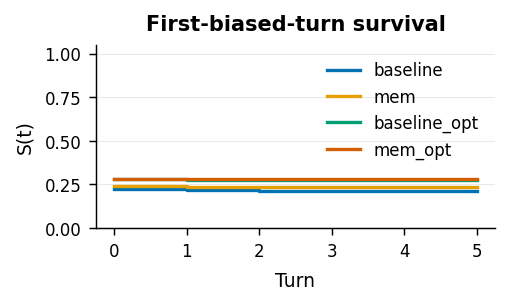

In [ ]:
sample_arms, round_arms = load_arms_paired()


def km_inputs(rd: pl.DataFrame):
    per_sample = (
        rd.sort(['sample_id', 'turn_index'])
        .group_by('sample_id', maintain_order=True)
        .agg([
            pl.col('first_biased_turn').drop_nulls().first().alias('fbt'),
            (pl.col('bias_prevalence') > 0).any().alias('any_bias'),
            pl.col('turn_index').max().alias('last_turn'),
        ])
    )

    def _duration(fbt, any_bias, last_turn):
        if any_bias:
            return int(fbt) if fbt is not None else int(last_turn) + 1
        return int(last_turn) + 1

    rows = list(per_sample.select(['fbt', 'any_bias', 'last_turn']).iter_rows())
    durations = list(starmap(_duration, rows))
    events = [any_bias for _, any_bias, _ in rows]

    return np.asarray(durations, dtype=float), np.asarray(events, dtype=bool)


km_inputs_per_arm = {arm: km_inputs(rd) for arm, rd in round_arms.items()}
km_per_arm = {arm: bm_surv.kaplan_meier(d, e, label=arm)
              for arm, (d, e) in km_inputs_per_arm.items()}
km_curves = {dn(arm): (est.timeline, est.survival) for arm, est in km_per_arm.items()}
fig = bm_fig.kaplan_meier_plot(km_curves, title='First-biased-turn survival')
fig.savefig(FIG_DIR / 'fig04_km_first_biased.pdf', bbox_inches='tight')
plt.show()


## Two-state Markov per arm

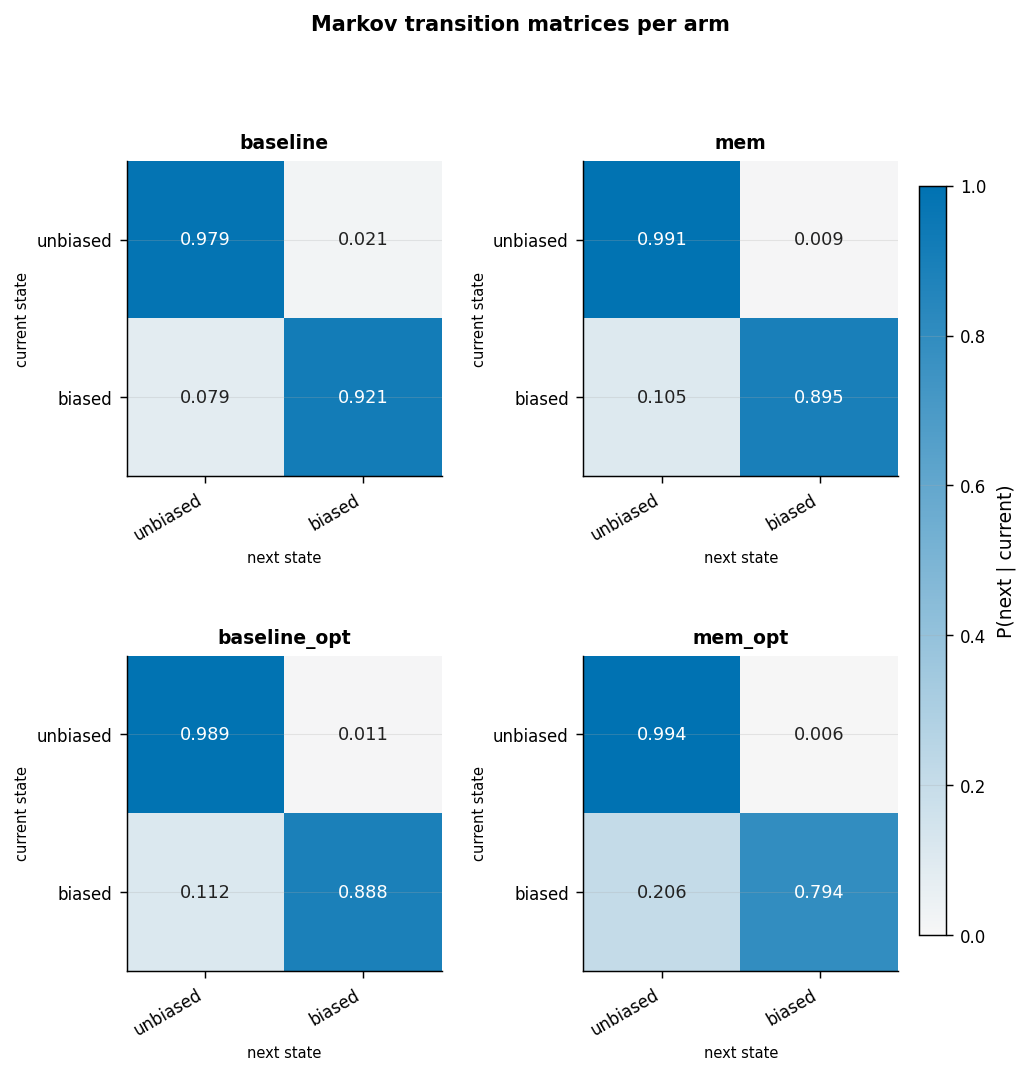

,baseline,mem0g,baseline_opt,mem0g_opt
P(0|0),0.979,0.991,0.989,0.994
P(1|0),0.021,0.009,0.011,0.006
P(0|1),0.079,0.105,0.112,0.206
P(1|1),0.921,0.895,0.888,0.794


In [ ]:
markov_per_arm = {arm: bm_dyn.fit_two_state_markov(rd) for arm, rd in round_arms.items()}
mat_per_arm = {arm: mk.P for arm, mk in markov_per_arm.items()}
fig = bm_fig.markov_heatmap(
    {dn(arm): mk.P for arm, mk in markov_per_arm.items()},
    state_labels=['unbiased', 'biased'])
fig.savefig(FIG_DIR / 'fig05_markov_heatmap.pdf', bbox_inches='tight')
plt.show()
pd.DataFrame({arm: mk.P.flatten() for arm, mk in markov_per_arm.items()},
             index=['P(0|0)', 'P(1|0)', 'P(0|1)', 'P(1|1)']).round(3)


## Recovery pictorial: P(recover at turn t)

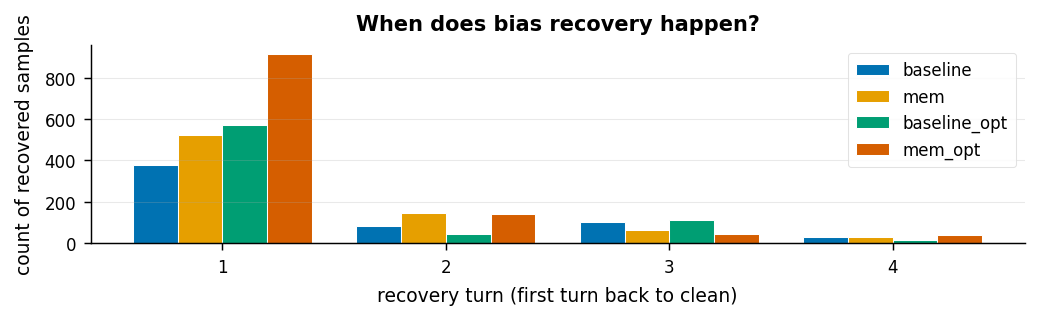

,baseline,mem0g,baseline_opt,mem0g_opt
turn,,,,
1,0.079,0.105,0.112,0.206
2,0.072,0.094,0.099,0.163
3,0.067,0.084,0.088,0.130
4,0.061,0.075,0.078,0.103


In [ ]:
# Theoretical PMF from Markov and empirical from lifecycle, side by side.
lc_per_arm = {arm: bm_lc.aggregate_lifecycle(bm_lc.derive_lifecycle(rd))
              for arm, rd in round_arms.items()}
emp_counts = {dn(arm): lc_per_arm[arm].recovery_turn_counts for arm in ARM_ORDER}
fig = bm_fig.recovery_time_histogram(emp_counts)
fig.savefig(FIG_DIR / 'fig06_recovery_pictorial.pdf', bbox_inches='tight')
plt.show()

recovery_pmf = {arm: list(mk.geometric_recovery_pmf(turns=4).values())
                for arm, mk in markov_per_arm.items()}
pmf_df = pd.DataFrame(recovery_pmf, index=range(1, 5))
pmf_df.index.name = 'turn'
pmf_df.round(3)


## Emergence vs recovery asymmetry

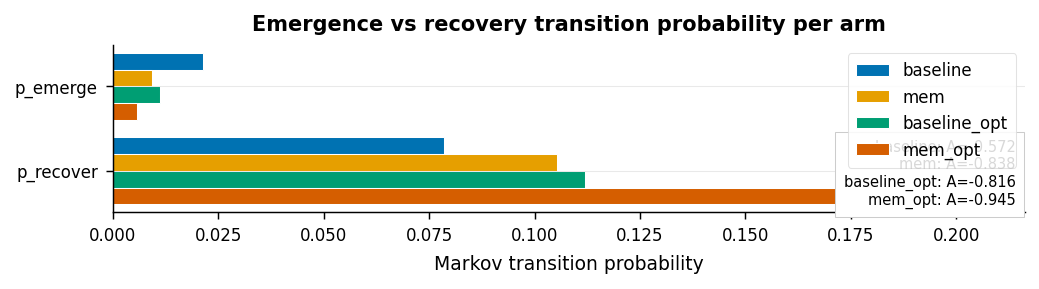

,arm,p_emerge,p_recover
0,baseline,0.021370,0.078503
1,mem,0.009284,0.105327
2,baseline_opt,0.011347,0.111850
3,mem_opt,0.005786,0.205831


In [ ]:
counts = {dn(arm): {'p_emerge': float(markov_per_arm[arm].p_emerge),
                    'p_recover': float(markov_per_arm[arm].p_recover)}
          for arm in ARM_ORDER}
fig = bm_fig.asymmetry_bar(
    counts,
    title='Emergence vs recovery transition probability per arm',
    xlabel='Markov transition probability',
)
fig.savefig(FIG_DIR / 'fig07_emerge_recover_asymmetry.pdf', bbox_inches='tight')
plt.show()
asym_df = pd.DataFrame(counts).T.reset_index().rename(columns={'index':'arm'})
asym_df


## Master JSON dump

In [ ]:
master = {
    'arms': list(ARM_ORDER),
    'km_summary': {arm: {'durations_n': len(km_inputs_per_arm[arm][0]),
                          'events_total': int(km_inputs_per_arm[arm][1].sum()),
                          'median_survival': float(km_per_arm[arm].median_survival_time)}
                   for arm in ARM_ORDER},
    'markov_matrix': {arm: mat_per_arm[arm].tolist() for arm in ARM_ORDER},
    'recovery_pmf': recovery_pmf,
    'asymmetry': json.loads(asym_df.to_json(orient='records')),
}
(OUT_DIR / 'notebook_02_master.json').write_text(json.dumps(master, indent=2, default=str))
print('wrote', OUT_DIR / 'notebook_02_master.json')


wrote /home/falcon/Projekte/IP-Claim/packages/bias-mitigation/notebooks/paper3_v2_outputs/notebook_02_master.json
